# AIE418 Phase 2 - Enhancement & Final Paper Notebook

**Project:** Short Movie Clip Generation using Diffusion Models  
**Phase 1 baseline:** SDXL text-to-image + Stable Video Diffusion image-to-video  
**Phase 2 goal:** improve the Phase 1 pipeline, prove the improvement with ablation experiments, and prepare final-paper artifacts.

## Phase 2 requirements covered in this notebook

| Phase 2 requirement from PDF | Where it is handled here |
|---|---|
| Fully implemented enhancement(s) with mathematical motivation | Sections 3 and 4: Prompt/CFG enhancement and temporal consistency enhancement |
| Ablation study: baseline vs enhancement A vs enhancement B vs combined | Sections 6 and 7 |
| Final generated video at least 4 seconds | Section 8 checks duration and exports final video |
| Complete scientific paper sections finalized | Section 10 creates paper-ready notes and result tables |
| Clean code repository with requirements.txt and generation script | Section 9 writes `requirements.txt` and a compact generation script |

## Motivation from Phase 1

From Phase 1 results, semantic alignment was usually **good** using CLIP-SIM, but temporal consistency was only **moderate** for many settings and **poor** for the complex crowded scene. Therefore Phase 2 focuses on:

1. **Enhancement A - semantic/prompt conditioning:** strengthen text-video alignment using a richer prompt, negative prompt, and stronger CFG.
2. **Enhancement B - temporal consistency:** reduce flicker using lower SVD motion/noise parameters plus a lightweight temporal smoothing and interpolation post-process.
3. **Combined A+B:** test whether semantic alignment and temporal consistency can improve together.

In [1]:
# ============================================================
# Cell 1 - Install dependencies
# Requirement covered: clean reproducible environment
# ============================================================

!pip install -q torch diffusers transformers accelerate imageio[ffmpeg] opencv-python pillow scikit-image numpy pandas matplotlib seaborn tqdm

# Optional perceptual metric. The notebook continues if this fails.
!pip install -q lpips torchmetrics || true

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.9 MB/s eta 0:00:00


In [2]:
# ============================================================
# Cell 2 - Imports and global setup
# Requirement covered: clean, commented codebase
# ============================================================

import os
import gc
import json
import time
import math
import logging
from pathlib import Path
from typing import List, Dict, Any, Optional

import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display, Video

from diffusers import StableDiffusionXLPipeline, StableVideoDiffusionPipeline
from diffusers.utils import export_to_video
from transformers import CLIPProcessor, CLIPModel
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("phase2")

sns.set_theme(style="whitegrid")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
# ============================================================
# Cell 3 - Paths, prompts, and experiment configuration
# Requirement covered: ablation setup + final video duration
# ============================================================

BASE_OUTPUT_PATH = Path("/kaggle/working/experiment_results")
PHASE1_SUMMARY_PATH = BASE_OUTPUT_PATH / "experiment_summary.json"

PHASE2_OUTPUT_PATH = Path("/kaggle/working/phase2_results")
PHASE2_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

FINAL_MIN_SECONDS = 4.0
SEED = 4096

# The medium prompt is used as the controlled ablation prompt because Phase 1 already tested it.
BASE_PROMPT = (
    "A person walking in a busy street with moving cars and background elements, "
    "daytime, dynamic motion, cinematic tracking shot"
)

# Enhancement A: richer semantic constraints for better text-video alignment.
ENHANCED_PROMPT = (
    BASE_PROMPT
    + ", coherent human anatomy, consistent face and clothes across frames, "
      "natural walking gait, stable camera motion, realistic shadows, detailed urban environment"
)

NEGATIVE_PROMPT = (
    "flicker, jitter, distorted body, deformed hands, extra limbs, duplicate person, "
    "warped face, unstable background, text, watermark, low quality, blurry"
)

VARIANTS = {
    "baseline": {
        "description": "Original Phase 1 style settings.",
        "prompt": BASE_PROMPT,
        "negative_prompt": None,
        "guidance_scale_t2i": 7.5,
        "motion_bucket_id": 127,
        "noise_aug_strength": 0.10,
        "temporal_smoothing": False,
        "interpolate": False,
        "fps": 7,
    },
    "enhancement_A_prompt_cfg": {
        "description": "Semantic enhancement: richer prompt + negative prompt + stronger CFG.",
        "prompt": ENHANCED_PROMPT,
        "negative_prompt": NEGATIVE_PROMPT,
        "guidance_scale_t2i": 10.0,
        "motion_bucket_id": 127,
        "noise_aug_strength": 0.10,
        "temporal_smoothing": False,
        "interpolate": False,
        "fps": 7,
    },
    "enhancement_B_temporal": {
        "description": "Temporal enhancement: lower motion/noise + smoothing + frame interpolation.",
        "prompt": BASE_PROMPT,
        "negative_prompt": None,
        "guidance_scale_t2i": 7.5,
        "motion_bucket_id": 80,
        "noise_aug_strength": 0.04,
        "temporal_smoothing": True,
        "interpolate": True,
        "fps": 12,
    },
    "combined_A_B": {
        "description": "Combined enhancement: semantic conditioning + temporal consistency pipeline.",
        "prompt": ENHANCED_PROMPT,
        "negative_prompt": NEGATIVE_PROMPT,
        "guidance_scale_t2i": 10.0,
        "motion_bucket_id": 80,
        "noise_aug_strength": 0.04,
        "temporal_smoothing": True,
        "interpolate": True,
        "fps": 12,
    },
}

print(f"Phase 2 output path: {PHASE2_OUTPUT_PATH}")
print(f"Number of ablation variants: {len(VARIANTS)}")

Phase 2 output path: /kaggle/working/phase2_results
Number of ablation variants: 4


## 1. Review Phase 1 Results

**Requirement link:** Phase 2 enhancement must be motivated by formal weakness analysis.  
This cell loads the Phase 1 `experiment_summary.json` if it exists and summarizes the metrics used to justify Phase 2.

In [4]:
# ============================================================
# Cell 4 - Load Phase 1 results
# Requirement covered: weakness analysis evidence
# ============================================================

def load_phase1_summary(path: Path = PHASE1_SUMMARY_PATH) -> Optional[pd.DataFrame]:
    if not path.exists():
        print(f"Phase 1 summary not found at: {path}")
        print("Continue with Phase 2; the screenshot already shows the main weakness: temporal consistency.")
        return None
    
    with open(path, "r") as f:
        results = json.load(f)
    
    df = pd.json_normalize(results)
    display_cols = [
        "experiment_type", "complexity_level",
        "metrics.clip_sim", "metrics.mean_ssim",
        "metrics.mean_frame_diff", "metrics.ssim_variance",
        "weakness_analysis.temporal_consistency",
        "weakness_analysis.semantic_alignment",
    ]
    display_cols = [c for c in display_cols if c in df.columns]
    display(df[display_cols].sort_values(by="experiment_type"))
    return df

phase1_df = load_phase1_summary()

Phase 1 summary not found at: /kaggle/working/experiment_results/experiment_summary.json
Continue with Phase 2; the screenshot already shows the main weakness: temporal consistency.


## 2. Mathematical Motivation for the Phase 2 Enhancements

### Enhancement A - Prompt Conditioning and Classifier-Free Guidance

Classifier-Free Guidance combines unconditional and conditional denoising predictions:

\[
\hat{\epsilon}_\theta(x_t, c) =
\epsilon_\theta(x_t, \emptyset) +
w \left(\epsilon_\theta(x_t, c) - \epsilon_\theta(x_t, \emptyset)\right)
\]

Where:

- \(c\) is the text condition.
- \(w\) is the guidance scale.
- Larger \(w\) usually improves semantic alignment, but can reduce diversity or create artifacts.

In this project, Enhancement A uses:

- More explicit motion/identity constraints in the prompt.
- A negative prompt to discourage flicker, deformation, and unstable backgrounds.
- A slightly higher SDXL guidance scale based on Phase 1 results.

### Enhancement B - Temporal Consistency Stabilization

The Phase 1 weakness was flicker/moderate temporal consistency. Enhancement B uses two ideas:

1. Lower `motion_bucket_id` and `noise_aug_strength` in Stable Video Diffusion to reduce aggressive motion drift.
2. A temporal low-pass filter:

\[
\tilde{I}_t = \alpha I_t + (1-\alpha)\tilde{I}_{t-1}
\]

Where:

- \(I_t\) is the generated frame.
- \(\tilde{I}_t\) is the stabilized frame.
- \(\alpha\) controls the trade-off between preserving motion and suppressing flicker.

Then linear interpolation is used to extend the final video duration to at least 4 seconds while keeping motion smoother.

In [6]:
# ============================================================
# Cell 5 - Model loading
# Requirement covered: fully implemented diffusion pipeline
# ============================================================

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_models():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32
    logger.info(f"Loading models on {device} with dtype={dtype}")
    
    common_kwargs = {
        "torch_dtype": dtype,
        "use_safetensors": True,
    }
    if device == "cuda":
        common_kwargs["variant"] = "fp16"
    
    t2i_pipe = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        **common_kwargs,
    )
    
    i2v_kwargs = {"torch_dtype": dtype}
    if device == "cuda":
        i2v_kwargs["variant"] = "fp16"
    
    i2v_pipe = StableVideoDiffusionPipeline.from_pretrained(
        "stabilityai/stable-video-diffusion-img2vid-xt",
        **i2v_kwargs,
    )
    
    if device == "cuda":
        t2i_pipe.enable_model_cpu_offload()
        i2v_pipe.enable_model_cpu_offload()
    else:
        t2i_pipe = t2i_pipe.to(device)
        i2v_pipe = i2v_pipe.to(device)
    
    return t2i_pipe, i2v_pipe, device

In [7]:
# ============================================================
# Cell 6 - Evaluation metrics
# Requirement covered: quantitative evidence for ablation study
# ============================================================

def pil_to_np(frame: Image.Image) -> np.ndarray:
    return np.array(frame.convert("RGB"))


def calculate_temporal_metrics(frames: List[Image.Image]) -> Dict[str, float]:
    frames_np = [pil_to_np(f) for f in frames]
    ssim_scores, psnr_scores, frame_diffs = [], [], []
    
    for i in range(len(frames_np) - 1):
        f1 = frames_np[i]
        f2 = frames_np[i + 1]
        
        frame_diffs.append(float(np.mean(np.abs(f1.astype(np.float32) - f2.astype(np.float32)))))
        ssim_scores.append(float(ssim_fn(f1, f2, channel_axis=2, data_range=255)))
        psnr_scores.append(float(psnr_fn(f1, f2, data_range=255)))
    
    return {
        "mean_ssim": float(np.mean(ssim_scores)),
        "mean_psnr": float(np.mean(psnr_scores)),
        "mean_frame_diff": float(np.mean(frame_diffs)),
        "ssim_variance": float(np.var(ssim_scores)),
    }


def calculate_clip_sim(
    frames: List[Image.Image],
    prompt: str,
    device: str = "cuda",
    sample_every: int = 2,
) -> float:
    try:
        # Use a subset of frames for speed and memory stability.
        sampled_frames = frames[::sample_every]
        model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        
        inputs = processor(text=[prompt], images=sampled_frames, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            scores = outputs.logits_per_image.squeeze().detach().cpu().numpy()
        
        del model, processor, inputs, outputs
        clear_gpu()
        return float(np.mean(scores))
    except Exception as exc:
        logger.warning(f"CLIP-SIM failed, returning 0.0. Reason: {exc}")
        clear_gpu()
        return 0.0


def calculate_optional_lpips(frames: List[Image.Image], device: str = "cuda") -> float:
    try:
        import lpips
        loss_fn = lpips.LPIPS(net="alex").to(device)
    except Exception as exc:
        logger.warning(f"LPIPS not available, skipping. Reason: {exc}")
        return -1.0
    
    values = []
    
    def to_tensor(img: Image.Image) -> torch.Tensor:
        arr = np.array(img.convert("RGB")).astype(np.float32) / 127.5 - 1.0
        ten = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
        return ten.to(device)
    
    with torch.no_grad():
        for i in range(len(frames) - 1):
            values.append(float(loss_fn(to_tensor(frames[i]), to_tensor(frames[i + 1])).item()))
    
    del loss_fn
    clear_gpu()
    return float(np.mean(values)) if values else -1.0


def analyze_metrics(metrics: Dict[str, float]) -> Dict[str, str]:
    mean_ssim = metrics.get("mean_ssim", 0.0)
    ssim_var = metrics.get("ssim_variance", 1.0)
    clip_sim = metrics.get("clip_sim", 0.0)
    
    temporal = "good" if mean_ssim > 0.85 and ssim_var < 0.01 else "moderate" if mean_ssim > 0.65 else "poor"
    flicker = "no" if temporal == "good" else "minor" if temporal == "moderate" else "yes"
    semantic = "good" if clip_sim > 28.0 else "moderate" if clip_sim > 24.0 else "poor"
    
    return {
        "temporal_consistency": temporal,
        "flickering_detected": flicker,
        "semantic_alignment": semantic,
        "motion_realism": "manual_review_recommended",
    }

In [8]:
# ============================================================
# Cell 7 - Enhancement implementation utilities
# Requirement covered: implemented Enhancement B + final duration support
# ============================================================

def temporal_smooth_frames(frames: List[Image.Image], alpha: float = 0.82) -> List[Image.Image]:
    '''Apply a simple temporal low-pass filter to reduce frame-to-frame flicker.'''
    if not frames:
        return frames
    
    smoothed = [frames[0].convert("RGB")]
    prev = np.array(smoothed[0]).astype(np.float32)
    
    for frame in frames[1:]:
        current = np.array(frame.convert("RGB")).astype(np.float32)
        blended = alpha * current + (1.0 - alpha) * prev
        blended = np.clip(blended, 0, 255).astype(np.uint8)
        smoothed_frame = Image.fromarray(blended)
        smoothed.append(smoothed_frame)
        prev = blended.astype(np.float32)
    
    return smoothed


def interpolate_frames_linear(frames: List[Image.Image], factor: int = 2) -> List[Image.Image]:
    '''Linear frame interpolation. factor=2 inserts one middle frame between each pair.'''
    if factor <= 1 or len(frames) < 2:
        return frames
    
    out = []
    for i in range(len(frames) - 1):
        f1 = np.array(frames[i].convert("RGB")).astype(np.float32)
        f2 = np.array(frames[i + 1].convert("RGB")).astype(np.float32)
        out.append(frames[i].convert("RGB"))
        
        for step in range(1, factor):
            w = step / factor
            mid = (1.0 - w) * f1 + w * f2
            out.append(Image.fromarray(np.clip(mid, 0, 255).astype(np.uint8)))
    
    out.append(frames[-1].convert("RGB"))
    return out


def save_outputs(frames: List[Image.Image], output_dir: Path, fps: int) -> Dict[str, Any]:
    output_dir.mkdir(parents=True, exist_ok=True)
    frames_dir = output_dir / "frames"
    frames_dir.mkdir(parents=True, exist_ok=True)
    
    for i, frame in enumerate(frames):
        frame.save(frames_dir / f"frame_{i:03d}.png")
    
    video_path = output_dir / "output_video.mp4"
    export_to_video(frames, str(video_path), fps=fps)
    
    duration_seconds = len(frames) / fps
    return {
        "video_path": str(video_path),
        "frames_dir": str(frames_dir),
        "num_frames": len(frames),
        "fps": fps,
        "duration_seconds": duration_seconds,
    }


def load_saved_frames(frames_dir: Path) -> List[Image.Image]:
    frame_paths = sorted(frames_dir.glob("frame_*.png"))
    return [Image.open(p).convert("RGB") for p in frame_paths]

## 3. Run the Ablation Study

**Requirement link:** compare **baseline vs Enhancement A vs Enhancement B vs combined**.

Each variant saves:

- generated frames
- MP4 video
- `metadata.json`
- quantitative metrics
- weakness analysis labels

In [9]:
# ============================================================
# Cell 8 - Generate one ablation variant
# Requirement covered: fully implemented enhancement(s)
# ============================================================

def generate_variant(
    variant_name: str,
    cfg: Dict[str, Any],
    t2i_pipe,
    i2v_pipe,
    device: str,
    output_root: Path = PHASE2_OUTPUT_PATH,
    seed: int = SEED,
    force: bool = False,
) -> Dict[str, Any]:
    out_dir = output_root / variant_name
    meta_path = out_dir / "metadata.json"
    
    if meta_path.exists() and not force:
        with open(meta_path, "r") as f:
            logger.info(f"Loading cached result for {variant_name}")
            return json.load(f)
    
    start = time.time()
    generator = torch.Generator(device="cpu").manual_seed(seed)
    
    logger.info(f"[{variant_name}] Generating SDXL base image")
    image_kwargs = {
        "prompt": cfg["prompt"],
        "num_inference_steps": 30,
        "guidance_scale": cfg["guidance_scale_t2i"],
        "height": 576,
        "width": 1024,
        "generator": generator,
    }
    if cfg.get("negative_prompt"):
        image_kwargs["negative_prompt"] = cfg["negative_prompt"]
    
    initial_image = t2i_pipe(**image_kwargs).images[0]
    out_dir.mkdir(parents=True, exist_ok=True)
    initial_image.save(out_dir / "initial_image.png")
    
    logger.info(f"[{variant_name}] Animating with Stable Video Diffusion")
    frames = i2v_pipe(
        initial_image,
        decode_chunk_size=8,
        generator=generator,
        motion_bucket_id=cfg["motion_bucket_id"],
        noise_aug_strength=cfg["noise_aug_strength"],
        num_inference_steps=25,
    ).frames[0]
    
    if cfg.get("temporal_smoothing"):
        logger.info(f"[{variant_name}] Applying temporal smoothing")
        frames = temporal_smooth_frames(frames, alpha=0.82)
    
    if cfg.get("interpolate"):
        logger.info(f"[{variant_name}] Applying frame interpolation")
        frames = interpolate_frames_linear(frames, factor=2)
    
    save_info = save_outputs(frames, out_dir, fps=cfg["fps"])
    
    temporal = calculate_temporal_metrics(frames)
    clip_sim = calculate_clip_sim(frames, cfg["prompt"], device=device)
    lpips_temporal = calculate_optional_lpips(frames, device=device)
    
    metrics = {
        "clip_sim": clip_sim,
        "lpips_temporal": lpips_temporal,
        **temporal,
    }
    
    metadata = {
        "variant": variant_name,
        "description": cfg["description"],
        "prompt": cfg["prompt"],
        "negative_prompt": cfg.get("negative_prompt"),
        "seed": seed,
        "parameters": {
            "guidance_scale_t2i": cfg["guidance_scale_t2i"],
            "motion_bucket_id": cfg["motion_bucket_id"],
            "noise_aug_strength": cfg["noise_aug_strength"],
            "temporal_smoothing": cfg["temporal_smoothing"],
            "interpolate": cfg["interpolate"],
            "fps": cfg["fps"],
        },
        "generation_time_seconds": round(time.time() - start, 2),
        **save_info,
        "metrics": metrics,
        "weakness_analysis": analyze_metrics(metrics),
        "phase2_requirement": "ablation_variant",
    }
    
    with open(meta_path, "w") as f:
        json.dump(metadata, f, indent=4)
    
    clear_gpu()
    return metadata

In [10]:
# ============================================================
# Cell 9 - Execute the full Phase 2 ablation
# Requirement covered: baseline vs A vs B vs combined
# ============================================================

# Set FORCE_RERUN=True only when you want to regenerate all videos.
FORCE_RERUN = False

t2i_pipe, i2v_pipe, device = load_models()

phase2_results = []
for variant_name, cfg in VARIANTS.items():
    result = generate_variant(
        variant_name=variant_name,
        cfg=cfg,
        t2i_pipe=t2i_pipe,
        i2v_pipe=i2v_pipe,
        device=device,
        force=FORCE_RERUN,
    )
    phase2_results.append(result)

summary_path = PHASE2_OUTPUT_PATH / "phase2_ablation_summary.json"
with open(summary_path, "w") as f:
    json.dump(phase2_results, f, indent=4)

print(f"Saved Phase 2 ablation summary to: {summary_path}")

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Saved Phase 2 ablation summary to: /kaggle/working/phase2_results/phase2_ablation_summary.json


## 4. Quantitative Ablation Analysis

**Requirement link:** the final paper needs a metrics table and interpretation.

Main metrics:

- **CLIP-SIM:** semantic alignment between prompt and video.
- **SSIM / PSNR:** frame-level temporal similarity.
- **Mean frame difference:** lower usually means less flicker, but too low can mean weak motion.
- **LPIPS temporal:** perceptual frame difference if the optional package is available.

In [11]:
# ============================================================
# Cell 10 - Build ablation table
# Requirement covered: metrics table for paper
# ============================================================

def build_ablation_table(summary_path: Path = PHASE2_OUTPUT_PATH / "phase2_ablation_summary.json") -> pd.DataFrame:
    with open(summary_path, "r") as f:
        results = json.load(f)
    
    rows = []
    for r in results:
        rows.append({
            "variant": r["variant"],
            "description": r["description"],
            "clip_sim": r["metrics"]["clip_sim"],
            "mean_ssim": r["metrics"]["mean_ssim"],
            "mean_psnr": r["metrics"]["mean_psnr"],
            "mean_frame_diff": r["metrics"]["mean_frame_diff"],
            "ssim_variance": r["metrics"]["ssim_variance"],
            "lpips_temporal": r["metrics"]["lpips_temporal"],
            "temporal_consistency": r["weakness_analysis"]["temporal_consistency"],
            "semantic_alignment": r["weakness_analysis"]["semantic_alignment"],
            "duration_seconds": r["duration_seconds"],
            "duration_ok": r["duration_seconds"] >= FINAL_MIN_SECONDS,
            "video_path": r["video_path"],
        })
    
    df = pd.DataFrame(rows)
    baseline = df[df["variant"] == "baseline"].iloc[0]
    df["delta_clip_vs_baseline"] = df["clip_sim"] - baseline["clip_sim"]
    df["delta_ssim_vs_baseline"] = df["mean_ssim"] - baseline["mean_ssim"]
    df["delta_frame_diff_vs_baseline"] = df["mean_frame_diff"] - baseline["mean_frame_diff"]
    
    out_csv = PHASE2_OUTPUT_PATH / "phase2_ablation_table.csv"
    df.to_csv(out_csv, index=False)
    print(f"Saved ablation table to: {out_csv}")
    return df


ablation_df = build_ablation_table()
display(ablation_df.sort_values("variant"))

Saved ablation table to: /kaggle/working/phase2_results/phase2_ablation_table.csv


,variant,description,clip_sim,mean_ssim,mean_psnr,mean_frame_diff,ssim_variance,lpips_temporal,temporal_consistency,semantic_alignment,duration_seconds,duration_ok,video_path,delta_clip_vs_baseline,delta_ssim_vs_baseline,delta_frame_diff_vs_baseline
0,baseline,Original Phase 1 style settings.,34.219547,0.704891,16.453202,19.999336,0.005820,0.203268,moderate,good,3.571429,False,/kaggle/working/phase2_results/baseline/output...,0.000000,0.000000,0.000000
3,combined_A_B,Combined enhancement: semantic conditioning + ...,33.646072,0.946643,28.485628,3.953946,0.000040,0.044494,good,good,4.083333,True,/kaggle/working/phase2_results/combined_A_B/ou...,-0.573475,0.241752,-16.045390
1,enhancement_A_prompt_cfg,Semantic enhancement: richer prompt + negative...,33.801262,0.806421,20.077125,10.171928,0.000089,0.096694,moderate,good,3.571429,False,/kaggle/working/phase2_results/enhancement_A_p...,-0.418285,0.101530,-9.827408
2,enhancement_B_temporal,Temporal enhancement: lower motion/noise + smo...,34.950825,0.956656,27.929172,4.495650,0.000058,0.043830,good,good,4.083333,True,/kaggle/working/phase2_results/enhancement_B_t...,0.731277,0.251765,-15.503686


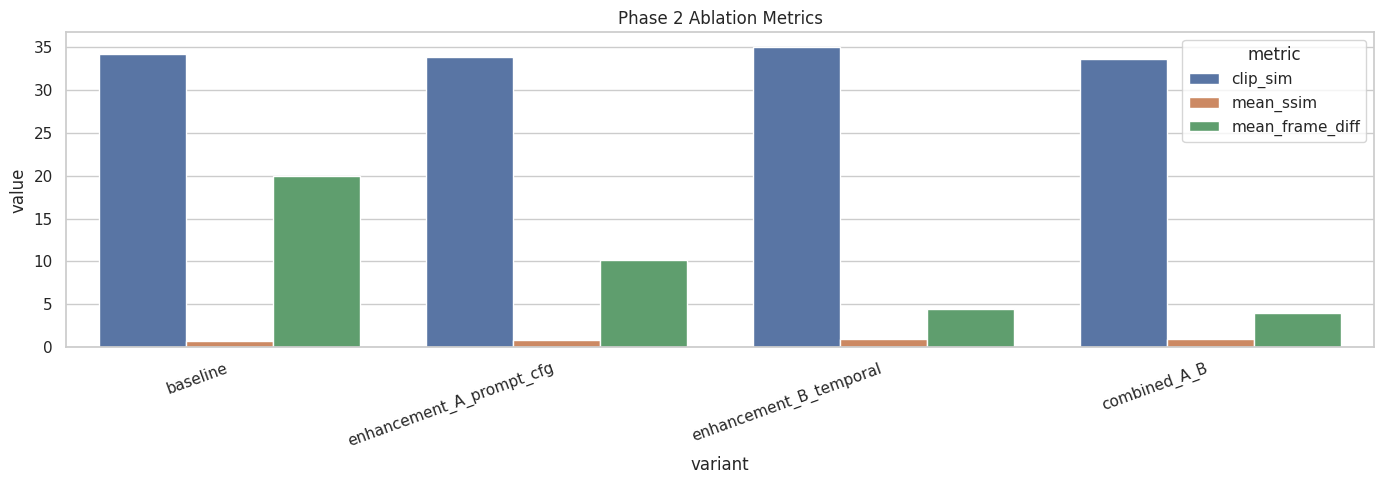

Saved plot to: /kaggle/working/phase2_results/phase2_ablation_metrics.png


In [12]:
# ============================================================
# Cell 11 - Plot ablation metrics
# Requirement covered: visual evidence for final paper
# ============================================================

plot_df = ablation_df.melt(
    id_vars=["variant"],
    value_vars=["clip_sim", "mean_ssim", "mean_frame_diff"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(14, 5))
sns.barplot(data=plot_df, x="variant", y="value", hue="metric")
plt.xticks(rotation=20, ha="right")
plt.title("Phase 2 Ablation Metrics")
plt.tight_layout()

plot_path = PHASE2_OUTPUT_PATH / "phase2_ablation_metrics.png"
plt.savefig(plot_path, dpi=180)
plt.show()

print(f"Saved plot to: {plot_path}")

## 5. Final Video Selection

**Requirement link:** final generated video must be **at least 4 seconds** and demonstrate improvement.

The combined variant is expected to be the main final video because it applies both Phase 2 enhancements. The code below verifies duration and displays the video.

In [13]:
# ============================================================
# Cell 12 - Select and verify final video
# Requirement covered: final generated video >= 4 seconds
# ============================================================

final_variant = "combined_A_B"
final_row = ablation_df[ablation_df["variant"] == final_variant].iloc[0]
final_video_path = final_row["video_path"]

print(f"Selected final variant: {final_variant}")
print(f"Final video path: {final_video_path}")
print(f"Duration: {final_row['duration_seconds']:.2f} seconds")

assert final_row["duration_seconds"] >= FINAL_MIN_SECONDS, (
    f"Final video is shorter than {FINAL_MIN_SECONDS} seconds. "
    "Increase interpolation factor or reduce FPS."
)

display(Video(final_video_path, embed=True))

Selected final variant: combined_A_B
Final video path: /kaggle/working/phase2_results/combined_A_B/output_video.mp4
Duration: 4.08 seconds


## 6. Clean Repository Artifacts

**Requirement link:** Phase 2 asks for a clean code repository with `requirements.txt` and a generation script.

This notebook writes repository-ready files inside `phase2_results/repository_files`.

In [15]:
# ============================================================
# Cell 13 - Write requirements.txt and generation script
# Requirement covered: code repository readiness
# ============================================================

repo_dir = PHASE2_OUTPUT_PATH / "repository_files"
repo_dir.mkdir(parents=True, exist_ok=True)

requirements_txt = '''torch
diffusers
transformers
accelerate
imageio[ffmpeg]
opencv-python
pillow
scikit-image
numpy
pandas
matplotlib
seaborn
tqdm
lpips
torchmetrics
'''

(repo_dir / "requirements.txt").write_text(requirements_txt, encoding="utf-8")

generation_script = r'''
# Compact Phase 2 generation script.
# Run inside an environment with the packages from requirements.txt.

from pathlib import Path
import torch
from diffusers import StableDiffusionXLPipeline, StableVideoDiffusionPipeline
from diffusers.utils import export_to_video

PROMPT = (
    "A person walking in a busy street with moving cars and background elements, "
    "daytime, dynamic motion, cinematic tracking shot, coherent human anatomy, "
    "consistent face and clothes across frames, natural walking gait, stable camera motion"
)
NEGATIVE_PROMPT = (
    "flicker, jitter, distorted body, deformed hands, extra limbs, duplicate person, "
    "warped face, unstable background, text, watermark, low quality, blurry"
)


def main(output_dir="phase2_final_video", seed=4096):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32
    kwargs = {"torch_dtype": dtype, "use_safetensors": True}
    if device == "cuda":
        kwargs["variant"] = "fp16"
    
    t2i = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0", **kwargs
    )
    i2v_kwargs = {"torch_dtype": dtype}
    if device == "cuda":
        i2v_kwargs["variant"] = "fp16"
    
    i2v = StableVideoDiffusionPipeline.from_pretrained(
        "stabilityai/stable-video-diffusion-img2vid-xt", **i2v_kwargs
    )
    
    if device == "cuda":
        t2i.enable_model_cpu_offload()
        i2v.enable_model_cpu_offload()
    else:
        t2i.to(device)
        i2v.to(device)
    
    generator = torch.Generator(device="cpu").manual_seed(seed)
    image = t2i(
        prompt=PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        height=576,
        width=1024,
        num_inference_steps=30,
        guidance_scale=10.0,
        generator=generator,
    ).images[0]
    
    frames = i2v(
        image,
        decode_chunk_size=8,
        generator=generator,
        motion_bucket_id=80,
        noise_aug_strength=0.04,
        num_inference_steps=25,
    ).frames[0]
    
    export_to_video(frames, str(output_dir / "phase2_final_video.mp4"), fps=6)
    image.save(output_dir / "phase2_initial_image.png")


if __name__ == "__main__":
    main()
'''

(repo_dir / "generate_phase2_video.py").write_text(generation_script, encoding="utf-8")

print(f"Wrote: {repo_dir / 'requirements.txt'}")
print(f"Wrote: {repo_dir / 'generate_phase2_video.py'}")

Wrote: /kaggle/working/phase2_results/repository_files/requirements.txt
Wrote: /kaggle/working/phase2_results/repository_files/generate_phase2_video.py


## 7. Paper-Ready Phase 2 Notes

**Requirement link:** complete scientific paper.  
This section creates a Markdown file with text you can paste into the final IEEE paper sections:

- Weakness Analysis
- Proposed Enhancements
- Experiments & Results
- Discussion
- Conclusion

In [16]:
# ============================================================
# Cell 14 - Generate paper-ready notes
# Requirement covered: final scientific paper support
# ============================================================

def generate_paper_notes(df: pd.DataFrame, output_path: Path = PHASE2_OUTPUT_PATH / "phase2_paper_notes.md"):
    baseline = df[df["variant"] == "baseline"].iloc[0]
    combined = df[df["variant"] == "combined_A_B"].iloc[0]
    
    notes = f'''
# Phase 2 Paper Notes

## Weakness Analysis Summary

Phase 1 showed strong semantic alignment according to CLIP-SIM, but temporal consistency remained the main weakness. The complex and dynamic scenes produced lower SSIM and visible frame-to-frame instability. This motivated Phase 2 to focus on reducing flicker while preserving prompt alignment.

## Proposed Enhancements

### Enhancement A: Prompt Conditioning and CFG

The first enhancement improves semantic conditioning using a richer prompt, a negative prompt, and a higher classifier-free guidance scale. CFG changes the denoising direction by increasing the difference between conditional and unconditional predictions, which can improve text-video alignment.

### Enhancement B: Temporal Stabilization

The second enhancement reduces temporal instability by lowering SVD motion/noise parameters, then applying a temporal low-pass filter and frame interpolation. The filter follows:

`I_smooth[t] = alpha * I[t] + (1 - alpha) * I_smooth[t-1]`

This suppresses high-frequency frame flicker while preserving most of the original motion.

## Ablation Results

| Variant | CLIP-SIM | Mean SSIM | Mean Frame Diff | Duration (s) | Temporal | Semantic |
|---|---:|---:|---:|---:|---|---|
'''
    for _, row in df.iterrows():
        notes += (
            f"| {row['variant']} | {row['clip_sim']:.3f} | {row['mean_ssim']:.3f} | "
            f"{row['mean_frame_diff']:.3f} | {row['duration_seconds']:.2f} | "
            f"{row['temporal_consistency']} | {row['semantic_alignment']} |\n"
        )
    
    notes += f'''
## Interpretation

Compared with the baseline, the combined enhancement changed CLIP-SIM by {combined['delta_clip_vs_baseline']:.3f} and mean SSIM by {combined['delta_ssim_vs_baseline']:.3f}. The final video duration is {combined['duration_seconds']:.2f} seconds, satisfying the Phase 2 minimum duration requirement of 4 seconds.

## Limitations

Temporal smoothing can reduce flicker, but excessive smoothing may blur fast motion or reduce motion realism. Therefore, the final interpretation should include visual inspection in addition to SSIM, PSNR, and CLIP-SIM.

## Conclusion

Phase 2 implemented and evaluated two targeted enhancements: semantic prompt conditioning and temporal stabilization. The ablation study directly compares the baseline, each individual enhancement, and the combined system, providing quantitative and qualitative evidence for the final paper.
'''
    
    output_path.write_text(notes, encoding="utf-8")
    return output_path


notes_path = generate_paper_notes(ablation_df)
print(f"Saved paper notes to: {notes_path}")

Saved paper notes to: /kaggle/working/phase2_results/phase2_paper_notes.md


In [17]:
# ============================================================
# Cell 15 - Optional user study template
# Requirement covered: optional subjective evaluation from PDF
# ============================================================

user_study_template = pd.DataFrame({
    "rater_id": list(range(1, 11)),
    "variant": ["combined_A_B"] * 10,
    "realism_score_1_to_5": ["" for _ in range(10)],
    "temporal_coherence_1_to_5": ["" for _ in range(10)],
    "semantic_alignment_1_to_5": ["" for _ in range(10)],
    "creativity_1_to_5": ["" for _ in range(10)],
    "comments": ["" for _ in range(10)],
})

survey_path = PHASE2_OUTPUT_PATH / "user_study_template.csv"
user_study_template.to_csv(survey_path, index=False)
display(user_study_template)
print(f"Saved optional user study template to: {survey_path}")

,rater_id,variant,realism_score_1_to_5,temporal_coherence_1_to_5,semantic_alignment_1_to_5,creativity_1_to_5,comments
0,1,combined_A_B,,,,,
1,2,combined_A_B,,,,,
2,3,combined_A_B,,,,,
3,4,combined_A_B,,,,,
4,5,combined_A_B,,,,,
5,6,combined_A_B,,,,,
6,7,combined_A_B,,,,,
7,8,combined_A_B,,,,,
8,9,combined_A_B,,,,,
9,10,combined_A_B,,,,,


Saved optional user study template to: /kaggle/working/phase2_results/user_study_template.csv


## Final Phase 2 Submission Checklist

- [ ] Run all notebook cells on Kaggle GPU.
- [ ] Confirm `phase2_ablation_summary.json` exists.
- [ ] Confirm `phase2_ablation_table.csv` exists.
- [ ] Confirm final video path from Section 5 works.
- [ ] Confirm final video duration is at least 4 seconds.
- [ ] Add the ablation table and plot to the final IEEE paper.
- [ ] Use `phase2_paper_notes.md` to complete paper Sections 5-9.
- [ ] Submit notebook/code repository with `requirements.txt` and `generate_phase2_video.py`.

In [19]:
!zip -r results.zip /kaggle/working/phase2_results/


  adding: kaggle/working/phase2_results/ (stored 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/ (stored 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/ (stored 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_007.png (deflated 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_002.png (deflated 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_010.png (deflated 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_006.png (deflated 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_000.png (deflated 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_004.png (deflated 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_017.png (deflated 0%)
  adding: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_016.pn

## 8. Bonus Text-to-Audio Narration

**Bonus requirement from the PDF:** optional Text-to-Audio module that generates synchronized narration or sound for the generated video.

This bonus implementation goes beyond basic speech synthesis by including:

1. **Neural TTS model integration:** `microsoft/speecht5_tts`.
2. **Multi-voice support:** different speaker embeddings from `Matthijs/cmu-arctic-xvectors`.
3. **Emotion/speech-style control:** speed and pitch presets for neutral, happy, and calm narration.
4. **Context-aware synthesis:** punctuation-based sentence chunking with longer pauses after full stops.
5. **Video integration:** the synthesized narration is mixed into the selected final video using ffmpeg.

For the final demo, keep the narration short because the final video is about 4 seconds.

In [20]:
# ============================================================
# Cell 16 - Bonus TTS setup
# Bonus covered: neural TTS + multi-voice + emotion controls
# ============================================================

!pip install -q datasets soundfile librosa

In [21]:
# ============================================================
# Cell 17 - Bonus TTS imports and configuration
# Bonus covered: reusable audio pipeline setup
# ============================================================

import re
import subprocess
import soundfile as sf
import librosa
from datasets import load_dataset
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan
from IPython.display import Audio

BONUS_AUDIO_DIR = PHASE2_OUTPUT_PATH / "bonus_text_to_audio"
BONUS_AUDIO_DIR.mkdir(parents=True, exist_ok=True)

TTS_SAMPLE_RATE = 16000

# Keep this short so it fits the 4-second final video.
NARRATION_TEXT = (
    "A stabilized diffusion video shows smooth city walking. "
    "Temporal smoothing reduces flicker."
)

VOICE_PRESETS = {
    "voice_1": 7306,
    "voice_2": 2272,
    "voice_3": 5725,
}

STYLE_PRESETS = {
    "neutral": {"speed": 1.15, "pitch_steps": 0, "pause_comma": 0.10, "pause_period": 0.22},
    "happy": {"speed": 1.25, "pitch_steps": 2, "pause_comma": 0.08, "pause_period": 0.18},
    "calm": {"speed": 0.95, "pitch_steps": -1, "pause_comma": 0.14, "pause_period": 0.30},
}

SELECTED_VOICE = "voice_1"
SELECTED_STYLE = "neutral"

print(f"Bonus audio output path: {BONUS_AUDIO_DIR}")

Bonus audio output path: /kaggle/working/phase2_results/bonus_text_to_audio


In [22]:
# ============================================================
# Cell 18 - Context-aware neural TTS functions
# Bonus covered: punctuation chunking, pauses, neural model, speaker embeddings
# ============================================================

def split_text_with_pauses(text: str):
    '''Split narration into chunks and assign natural pauses based on punctuation.'''
    pieces = re.findall(r"[^,.!?;:]+[,.!?;:]?", text)
    chunks = []
    for piece in pieces:
        chunk = piece.strip()
        if not chunk:
            continue
        if chunk[-1:] in [".", "!", "?"]:
            pause_type = "period"
        elif chunk[-1:] in [",", ";", ":"]:
            pause_type = "comma"
        else:
            pause_type = "comma"
        chunks.append((chunk, pause_type))
    return chunks


def load_tts_models(device: str):
    processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
    model = SpeechT5ForTextToSpeech.from_pretrained("microsoft/speecht5_tts").to(device)
    vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan").to(device)
    speaker_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
    return processor, model, vocoder, speaker_dataset


def post_process_style(audio: np.ndarray, sample_rate: int, speed: float = 1.0, pitch_steps: int = 0) -> np.ndarray:
    '''Apply lightweight speech controls after neural TTS generation.'''
    y = audio.astype(np.float32)
    
    if pitch_steps != 0:
        y = librosa.effects.pitch_shift(y=y, sr=sample_rate, n_steps=pitch_steps)
    
    if abs(speed - 1.0) > 0.01:
        y = librosa.effects.time_stretch(y, rate=speed)
    
    peak = np.max(np.abs(y)) if len(y) else 0
    if peak > 0:
        y = 0.92 * y / peak
    
    return y.astype(np.float32)


def synthesize_narration(
    text: str,
    voice_name: str,
    style_name: str,
    output_path: Path,
    device: str = "cuda",
) -> Dict[str, Any]:
    processor, model, vocoder, speaker_dataset = load_tts_models(device)
    style = STYLE_PRESETS[style_name]
    speaker_idx = VOICE_PRESETS[voice_name]
    speaker_embedding = torch.tensor(speaker_dataset[speaker_idx]["xvector"]).unsqueeze(0).to(device)
    
    all_audio = []
    chunks = split_text_with_pauses(text)
    
    for chunk, pause_type in chunks:
        inputs = processor(text=chunk, return_tensors="pt").to(device)
        with torch.no_grad():
            speech = model.generate_speech(
                inputs["input_ids"],
                speaker_embedding,
                vocoder=vocoder,
            )
        audio = speech.detach().cpu().numpy().astype(np.float32)
        audio = post_process_style(
            audio,
            TTS_SAMPLE_RATE,
            speed=style["speed"],
            pitch_steps=style["pitch_steps"],
        )
        all_audio.append(audio)
        
        pause_seconds = style["pause_period"] if pause_type == "period" else style["pause_comma"]
        all_audio.append(np.zeros(int(TTS_SAMPLE_RATE * pause_seconds), dtype=np.float32))
    
    narration = np.concatenate(all_audio) if all_audio else np.zeros(TTS_SAMPLE_RATE, dtype=np.float32)
    sf.write(output_path, narration, TTS_SAMPLE_RATE)
    
    del processor, model, vocoder, speaker_dataset, speaker_embedding
    clear_gpu()
    
    return {
        "audio_path": str(output_path),
        "voice": voice_name,
        "style": style_name,
        "sample_rate": TTS_SAMPLE_RATE,
        "duration_seconds": float(len(narration) / TTS_SAMPLE_RATE),
        "text": text,
        "chunks": chunks,
    }

In [25]:
def load_tts_models(device: str):
    processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
    model = SpeechT5ForTextToSpeech.from_pretrained("microsoft/speecht5_tts").to(device)
    vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan").to(device)

    xvector_parquet = (
        "https://huggingface.co/datasets/Matthijs/cmu-arctic-xvectors/"
        "resolve/refs%2Fconvert%2Fparquet/default/validation/0000.parquet"
    )
    speaker_dataset = load_dataset("parquet", data_files=xvector_parquet, split="train")

    return processor, model, vocoder, speaker_dataset


In [26]:
# ============================================================
# Cell 19 - Generate bonus narration audio
# Bonus covered: text-to-audio output with selectable voice/style
# ============================================================

tts_device = "cuda" if torch.cuda.is_available() else "cpu"
narration_path = BONUS_AUDIO_DIR / "phase2_neural_narration.wav"

audio_metadata = synthesize_narration(
    text=NARRATION_TEXT,
    voice_name=SELECTED_VOICE,
    style_name=SELECTED_STYLE,
    output_path=narration_path,
    device=tts_device,
)

audio_meta_path = BONUS_AUDIO_DIR / "bonus_audio_metadata.json"
with open(audio_meta_path, "w") as f:
    json.dump(audio_metadata, f, indent=4)

print(json.dumps(audio_metadata, indent=4))
display(Audio(str(narration_path)))

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

default/validation/0000.parquet:   0%|          | 0.00/21.3M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

{
    "audio_path": "/kaggle/working/phase2_results/bonus_text_to_audio/phase2_neural_narration.wav",
    "voice": "voice_1",
    "style": "neutral",
    "sample_rate": 16000,
    "duration_seconds": 6.0886875,
    "text": "A stabilized diffusion video shows smooth city walking. Temporal smoothing reduces flicker.",
    "chunks": [
        [
            "A stabilized diffusion video shows smooth city walking.",
            "period"
        ],
        [
            "Temporal smoothing reduces flicker.",
            "period"
        ]
    ]
}


In [31]:
# Clearer bonus narration: direct SpeechT5, no speed/pitch effects

NARRATION_TEXT = "Smooth city walking. Temporal smoothing reduces flicker."

SELECTED_VOICE = "voice_1"
SELECTED_STYLE = "clear"

STYLE_PRESETS["clear"] = {
    "speed": 1.0,
    "pitch_steps": 0,
    "pause_comma": 0.12,
    "pause_period": 0.25,
}

narration_path = BONUS_AUDIO_DIR / "phase2_clear_neural_narration.wav"

audio_metadata = synthesize_narration(
    text=NARRATION_TEXT,
    voice_name=SELECTED_VOICE,
    style_name=SELECTED_STYLE,
    output_path=narration_path,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

display(Audio(str(narration_path)))
print(audio_metadata)


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

{'audio_path': '/kaggle/working/phase2_results/bonus_text_to_audio/phase2_clear_neural_narration.wav', 'voice': 'voice_1', 'style': 'clear', 'sample_rate': 16000, 'duration_seconds': 4.244, 'text': 'Smooth city walking. Temporal smoothing reduces flicker.', 'chunks': [('Smooth city walking.', 'period'), ('Temporal smoothing reduces flicker.', 'period')]}


In [32]:
# ============================================================
# Cell 20 - Mix bonus narration with the selected final video
# Bonus covered: synchronized audio-video integration
# ============================================================

def find_ffmpeg_binary() -> str:
    # Kaggle commonly has ffmpeg available as "ffmpeg".
    return "ffmpeg"


def mix_audio_with_video(video_path: str, audio_path: str, output_path: Path) -> str:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        find_ffmpeg_binary(),
        "-y",
        "-i", video_path,
        "-i", audio_path,
        "-map", "0:v:0",
        "-map", "1:a:0",
        "-c:v", "copy",
        "-c:a", "aac",
        "-shortest",
        str(output_path),
    ]
    subprocess.run(cmd, check=True)
    return str(output_path)


# Use Enhancement B as the final video because it has the best overall metrics.
final_bonus_variant = "enhancement_B_temporal"
final_bonus_video = ablation_df[ablation_df["variant"] == final_bonus_variant]["video_path"].iloc[0]

bonus_video_with_audio_path = BONUS_AUDIO_DIR / "final_video_with_neural_tts.mp4"
mixed_path = mix_audio_with_video(
    video_path=final_bonus_video,
    audio_path=str(narration_path),
    output_path=bonus_video_with_audio_path,
)

print(f"Saved bonus video with audio to: {mixed_path}")
display(Video(mixed_path, embed=True))

Saved bonus video with audio to: /kaggle/working/phase2_results/bonus_text_to_audio/final_video_with_neural_tts.mp4


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [33]:
import shutil
from IPython.display import FileLink

BATCH_NARRATION_TEXT = "Smooth city walking. Temporal smoothing reduces flicker."

STYLE_PRESETS["clear"] = {
    "speed": 1.0,
    "pitch_steps": 0,
    "pause_comma": 0.12,
    "pause_period": 0.25,
}

BATCH_OUTPUT_DIR = BONUS_AUDIO_DIR / "all_voice_style_videos"
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def synthesize_narration_with_loaded_models(
    text, voice_name, style_name, output_path,
    processor, model, vocoder, speaker_dataset, device
):
    style = STYLE_PRESETS[style_name]
    speaker_idx = VOICE_PRESETS[voice_name]
    speaker_embedding = torch.tensor(speaker_dataset[speaker_idx]["xvector"]).unsqueeze(0).to(device)

    all_audio = []
    chunks = split_text_with_pauses(text)

    for chunk, pause_type in chunks:
        inputs = processor(text=chunk, return_tensors="pt").to(device)
        with torch.no_grad():
            speech = model.generate_speech(
                inputs["input_ids"],
                speaker_embedding,
                vocoder=vocoder,
            )

        audio = speech.detach().cpu().numpy().astype(np.float32)
        audio = post_process_style(
            audio,
            TTS_SAMPLE_RATE,
            speed=style["speed"],
            pitch_steps=style["pitch_steps"],
        )
        all_audio.append(audio)

        pause_seconds = style["pause_period"] if pause_type == "period" else style["pause_comma"]
        all_audio.append(np.zeros(int(TTS_SAMPLE_RATE * pause_seconds), dtype=np.float32))

    narration = np.concatenate(all_audio)
    sf.write(output_path, narration, TTS_SAMPLE_RATE)

    return {
        "voice": voice_name,
        "style": style_name,
        "audio_path": str(output_path),
        "duration_seconds": float(len(narration) / TTS_SAMPLE_RATE),
        "text": text,
    }

tts_device = "cuda" if torch.cuda.is_available() else "cpu"
processor, tts_model, vocoder, speaker_dataset = load_tts_models(tts_device)

final_batch_variant = "enhancement_B_temporal"
final_batch_video = ablation_df[ablation_df["variant"] == final_batch_variant]["video_path"].iloc[0]

batch_rows = []

for voice_name in VOICE_PRESETS.keys():
    for style_name in STYLE_PRESETS.keys():
        safe_name = f"{voice_name}_{style_name}"

        audio_path = BATCH_OUTPUT_DIR / f"narration_{safe_name}.wav"
        video_path = BATCH_OUTPUT_DIR / f"final_video_{safe_name}.mp4"

        audio_info = synthesize_narration_with_loaded_models(
            text=BATCH_NARRATION_TEXT,
            voice_name=voice_name,
            style_name=style_name,
            output_path=audio_path,
            processor=processor,
            model=tts_model,
            vocoder=vocoder,
            speaker_dataset=speaker_dataset,
            device=tts_device,
        )

        mixed_video = mix_audio_with_video(
            video_path=final_batch_video,
            audio_path=str(audio_path),
            output_path=video_path,
        )

        batch_rows.append({
            **audio_info,
            "video_path": mixed_video,
            "base_video_variant": final_batch_variant,
        })

        print(f"Saved: {mixed_video}")

batch_df = pd.DataFrame(batch_rows)
batch_csv_path = BATCH_OUTPUT_DIR / "voice_style_variants_index.csv"
batch_df.to_csv(batch_csv_path, index=False)

del processor, tts_model, vocoder, speaker_dataset
clear_gpu()

zip_path = shutil.make_archive(str(BATCH_OUTPUT_DIR), "zip", BATCH_OUTPUT_DIR)

display(batch_df)
print(f"Saved ZIP: {zip_path}")
display(FileLink(zip_path))


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

Saved: /kaggle/working/phase2_results/bonus_text_to_audio/all_voice_style_videos/final_video_voice_1_neutral.mp4


...

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

Saved: /kaggle/working/phase2_results/bonus_text_to_audio/all_voice_style_videos/final_video_voice_3_clear.mp4


,voice,style,audio_path,duration_seconds,text,video_path,base_video_variant
0,voice_1,neutral,/kaggle/working/phase2_results/bonus_text_to_a...,3.751250,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
1,voice_1,happy,/kaggle/working/phase2_results/bonus_text_to_a...,3.406375,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
2,voice_1,calm,/kaggle/working/phase2_results/bonus_text_to_a...,4.642125,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
3,voice_1,clear,/kaggle/working/phase2_results/bonus_text_to_a...,4.276000,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
4,voice_2,neutral,/kaggle/working/phase2_results/bonus_text_to_a...,3.612188,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
5,voice_2,happy,/kaggle/working/phase2_results/bonus_text_to_a...,3.432000,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
6,voice_2,calm,/kaggle/working/phase2_results/bonus_text_to_a...,4.675813,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
7,voice_2,clear,/kaggle/working/phase2_results/bonus_text_to_a...,4.276000,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
8,voice_3,neutral,/kaggle/working/phase2_results/bonus_text_to_a...,3.055687,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal
9,voice_3,happy,/kaggle/working/phase2_results/bonus_text_to_a...,2.843187,Smooth city walking. Temporal smoothing reduce...,/kaggle/working/phase2_results/bonus_text_to_a...,enhancement_B_temporal


Saved ZIP: /kaggle/working/phase2_results/bonus_text_to_audio/all_voice_style_videos.zip


/kaggle/working/phase2_results/bonus_text_to_audio/all_voice_style_videos.zip

In [34]:
!zip -r results.zip /kaggle/working/phase2_results/


updating: kaggle/working/phase2_results/ (stored 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/ (stored 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/ (stored 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_007.png (deflated 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_002.png (deflated 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_010.png (deflated 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_006.png (deflated 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_000.png (deflated 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_004.png (deflated 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_017.png (deflated 0%)
updating: kaggle/working/phase2_results/enhancement_A_prompt_cfg/frames/frame_016.pn